# More Axes    

In the last tutorial, we were introduced to figures and axes. We then spent some time learning about some of the parameters and methods we can use with figures. In this tutorial we are going to go a deeper on how to create axes inside a figure.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# Set random seed for reproducibility
np.random.seed(2026)

## fig.add_axes()

While not the most common way to create axes (more below), the most explicit way to add an Axes is using `fig.add_axes([left, bottom, width, height])`. This gives you complete control over positioning.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

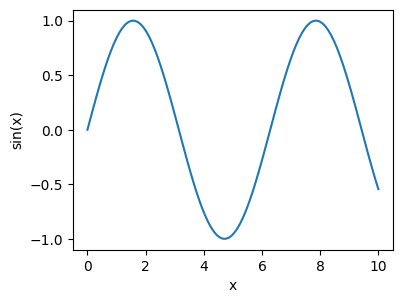

In [3]:
fig = plt.figure(figsize=(4, 3))

# Create Data
x = np.linspace(0, 10, 100)

# Add an axes: [left, bottom, width, height] in figure coordinates (0 to 1)
ax = fig.add_axes([0.1, 0.1 ,0.8, 0.8])

# Plot some data
ax.plot(x, np.sin(x))
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
plt.show()

We can find out what are the bounds associated with some axes.

In [4]:
ax.get_position().bounds

(np.float64(0.1), np.float64(0.1), np.float64(0.8), np.float64(0.8))

**Understanding Figure Coordinates:**
- `[left, bottom, width, height]` all range from 0 to 1, known as ***Normalized** figure coordinates* (more later)
- `(0, 0)` is the bottom-left corner of the figure
- `(1, 1)` is the top-right corner of the figure
- `left=0.1` means start 10% of the figure width from the left edge
- `width=0.8` means take up 80% of the figure width


### Creating Inset Axes

One advantage of manual positioning is you can create overlapping axes, which is useful for insets or comparison plots.

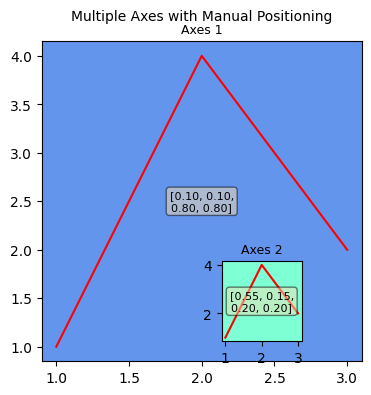

In [5]:
# Visualize different positions
fig = plt.figure(figsize=(4,4))

# Create two axes
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # left, bottom, width, height
ax2 = fig.add_axes([0.55, 0.15, 0.2, 0.2]) # left, bottom, width, height
facecolors=['cornflowerblue', 'aquamarine']

# Add data to each
for i, ax in enumerate([ax1, ax2], 1):
    ax.plot([1, 2, 3], [1, 4, 2], color ='red') # plot a line
    ax.set_title(f'Axes {i}', fontsize=9) # add a tile to each axes
    ax.set_facecolor(facecolors[i-1])# facecolor
     # retrieve the bounds of each axes
    pos = ax.get_position().bounds
    ax.text(0.5, 0.5, f'[{pos[0]:.2f}, {pos[1]:.2f},\n{pos[2]:.2f}, {pos[3]:.2f}]',
            transform=ax.transAxes, ha='center', va='center', size= 8, #what going on here?
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add a main title
fig.suptitle('Multiple Axes with Manual Positioning', x=0.5, ha='center',fontsize=10)
plt.show()

### Creating Axes with Custom Aspect Ratios

Manual positioning is perfect when you need specific aspect ratios or unconventional layouts.

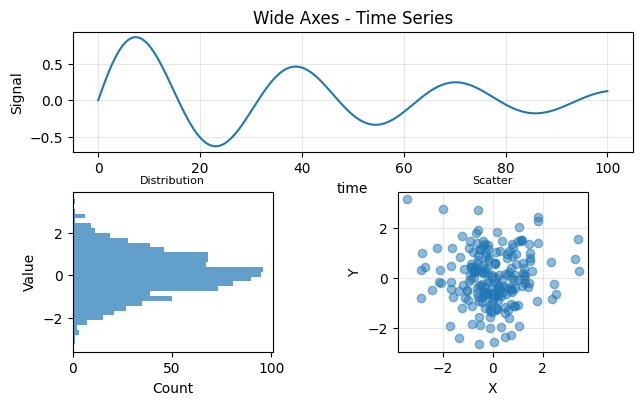

In [6]:
fig = plt.figure(figsize=(8, 4))

# Wide axes (good for time series)
ax_wide = fig.add_axes([0.1, 0.55, 0.7, 0.3])
time = np.linspace(0,100, 1000)
ax_wide.plot(time, np.sin(time/5) * np.exp(-time/50))
ax_wide.set_xlabel('time') # xlabel Time
ax_wide.set_ylabel('Signal')# ylabel Signal
ax_wide.set_title('Wide Axes - Time Series')
ax_wide.grid(True, alpha=0.3)

# Axes1
ax1 = fig.add_axes([0.1, 0.05, 0.25, 0.4])
data = np.random.randn(1000)
ax1.hist(data, bins=30, orientation='horizontal', alpha=0.7)
ax1.set_ylabel('Value')
ax1.set_xlabel('Count')
ax1.set_title('Distribution', size= 8)

# Axes2
ax2 = fig.add_axes([0.5, 0.05, 0.25, 0.4])
x_scatter = np.random.randn(200)
y_scatter = np.random.randn(200)
ax2.scatter(x_scatter, y_scatter, alpha=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Scatter', size= 8)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
plt.show()

#### When to Use Manual Positioning

Use `fig.add_axes()` when you need:
- Precise control over axes position and size
- Overlapping or inset axes
- Non-uniform layouts
- Custom aspect ratios
- Complex, non-grid-based layouts

Manual positioning with `fig.add_axes()` gives you complete control over axes placement, perfect for custom layouts, insets, and non-standard designs.

**Don't use it when:**
- You want a simple grid of subplots → use `plt.subplots()`
- You want automatic spacing → use GridSpec
- You're creating standard layouts → use higher-level functions

## fig.add_subplot()

If we are not interested in fine control over the exact location and size of an axes we can use instead the  `.add_subplot()`.

**`add_subplot()` main parameters:**
- `nrows`:  number of rows in the subplot grid
- `ncols`: number of columns
- `index`: position in the grid (1‑based, left‑to‑right, top‑to‑bottom)

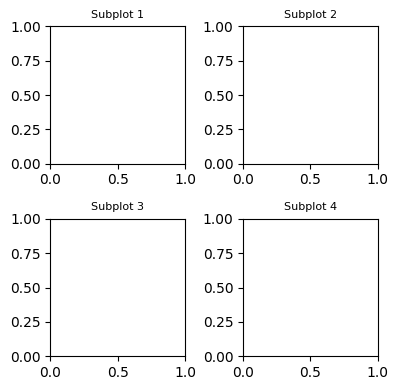

In [7]:
fig = plt.figure(figsize=(4, 4))#Could the subplots below be created here all in one go??

# add_subplot(nrows, ncols, index)
# Creates a grid of nrows x ncols, and selects the index'th subplot

ax1 = fig.add_subplot(2, 2, 1)  # 2 rows, 2 cols, position 1 (top-left)
ax2 = fig.add_subplot(2, 2, 2)  # 2 rows, 2 cols, position 2 (top-right)
ax3 = fig.add_subplot(2, 2, 3)  # 2 rows, 2 cols, position 3 (bottom-left)
ax4 = fig.add_subplot(2, 2, 4)  # 2 rows, 2 cols, position 4 (bottom-right)

# Set titles
ax1.set_title('Subplot 1', fontsize=8)
ax2.set_title('Subplot 2', fontsize=8)
ax3.set_title('Subplot 3', fontsize=8)
ax4.set_title('Subplot 4', fontsize=8)

fig.tight_layout()
plt.show()

```{note} Noticed that position of each figure starts at the top towards the right until it finished in the bottom left. It is also possible to specify a position in abbreviated form.
```

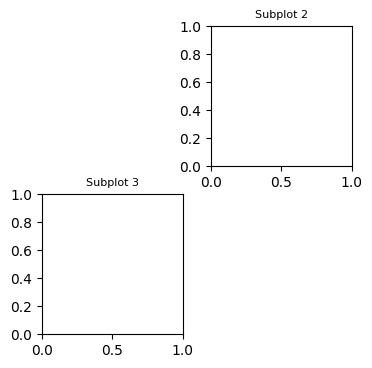

In [8]:
fig = plt.figure(figsize=(4, 4))

# Abbreviated form
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)

# Set titles
ax2.set_title('Subplot 2', fontsize = 8)
ax3.set_title('Subplot 3', fontsize = 8)

plt.show()

## Creating Figures and Axes Together
 
While `fig.add_axes()` gives precise control, most of the time you want to quickly create a figure with axes. The `plt.subplots()` function is the most common and convenient way to do this in the object-oriented interface.

### Creating a Single Subplot

When you call `plt.subplots()` with no arguments (or with `nrows=1, ncols=1`), it returns a single Axes object.

```{attention}
The following are equivalent:
- `plt.subplots()`
- `plt.subplot(111)`
- `plt.subplot(1,1,1)`
```

In [9]:
import matplotlib.pyplot as plt
import numpy as np

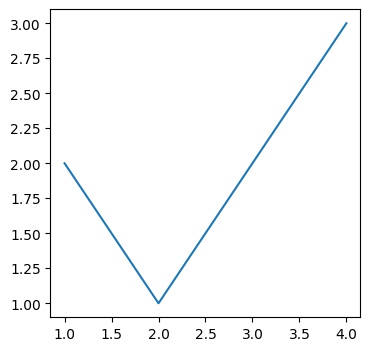

In [10]:
# Create a figure and a single axes
fig, ax = plt.subplots(figsize=(4,4))

# Plot some data
ax.plot([1,2,3,4], [2,1,2,3])

plt.show()

```{important}
`plt.subplots()` always returns a tuple: `(fig, ax)` or `(fig, axes)`: 
- `fig`: The Figure object
- `ax`: A single (if creating one subplot) or multiple (if creating multiple subplots) Axes objects 
```
**This is different from:**
- `plt.subplot()` (MATLAB-style, not recommended)
- `fig.add_subplot()` (adding subplots incrementally

#### Customizing the Figure in `plt.subplots()`

You can pass the same parameters as `plt.figure()` to customize the figure.

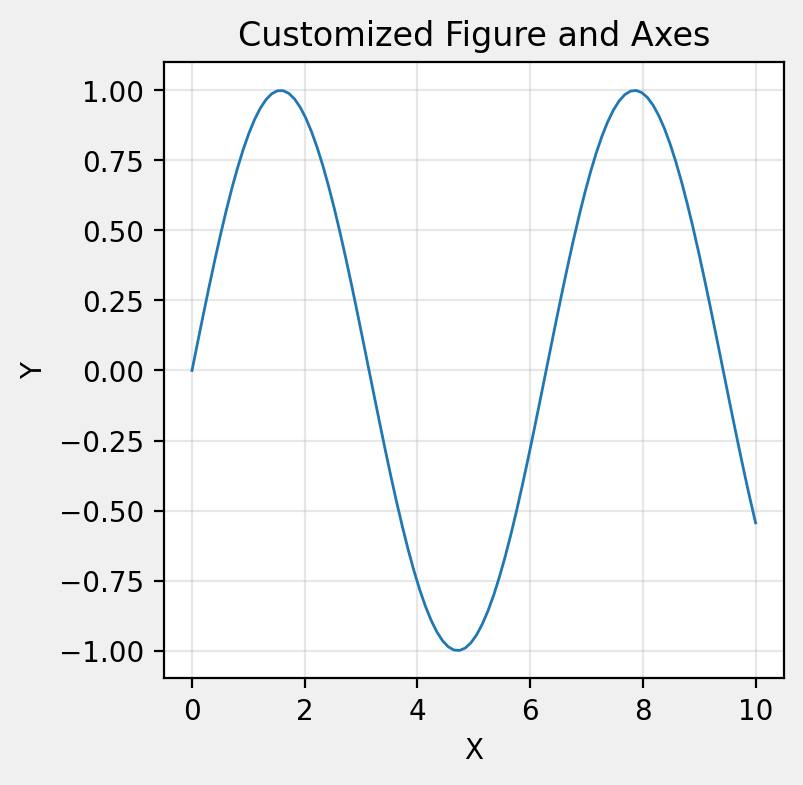

In [11]:
# Create data
x = np.linspace(0, 10, 100)

# Create figure with custom properties
fig, ax = plt.subplots(
       figsize=(4,4), # Figure size
       dpi = 200, # Resolution
       facecolor = '#F0F0F0', # Figure background
)

# Customize axes
ax.set_facecolor('#FFFFFF')    # Axes background
ax.set_xlabel('X', fontsize=10)
ax.set_ylabel('Y', fontsize=10)
ax.set_title('Customized Figure and Axes', fontsize=12)
ax.grid(True, alpha=0.3)
ax.plot(x, np.sin(x), linewidth=1)
plt.show()

### Creating Multiple Subplots   
The power of `plt.subplots()` becomes apparent when creating multiple subplots.

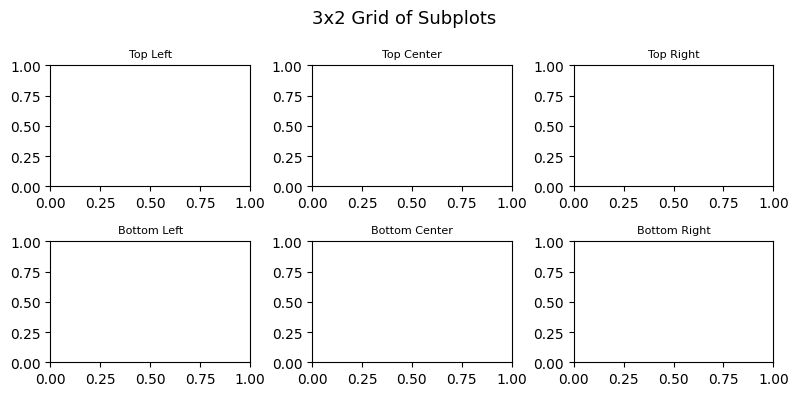

In [12]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(8, 4))#Does this also create the figure??
# Access individual axes using array indexing
axes[0, 0].set_title('Top Left', size= 8) # size is short for fontsize
axes[0, 1].set_title('Top Center', size= 8)
axes[0, 2].set_title('Top Right', size= 8) # Top Right
axes[1, 0].set_title('Bottom Left', size= 8)
axes[1, 1].set_title('Bottom Center', size= 8) #Bottom Center
axes[1, 2].set_title('Bottom Right', size= 8)

# Set the title for the entire figure
fig.suptitle('3x2 Grid of Subplots', fontsize=13)
fig.tight_layout()

**Understanding the axes array:**
- For a 3x2 grid: `axes.shape` is `(3, 2)`
- Access using: `axes[row, col]`
- Row 0 is the top row
- Column 0 is the left column
- It's a NumPy array, so you can use array operations (Which are??)

In [13]:
axes

array([[<Axes: title={'center': 'Top Left'}>,
        <Axes: title={'center': 'Top Center'}>,
        <Axes: title={'center': 'Top Right'}>],
       [<Axes: title={'center': 'Bottom Left'}>,
        <Axes: title={'center': 'Bottom Center'}>,
        <Axes: title={'center': 'Bottom Right'}>]], dtype=object)

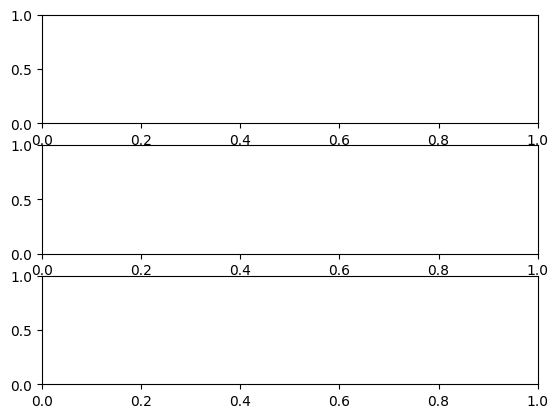

In [14]:
fig, axes = plt.subplots(3,1)

```{caution}
If you specify a single row or column, you get a 1D array of axes.
```

#### Iterating Over Axes

Since axes is a NumPy array, you can iterate over it easily. You can achieve this by 'flattening' a the 2D array into a 1D array. These can be achieved using two different numpy operations:
- `np.flatten()` OR
- `np.ravel()`

findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.


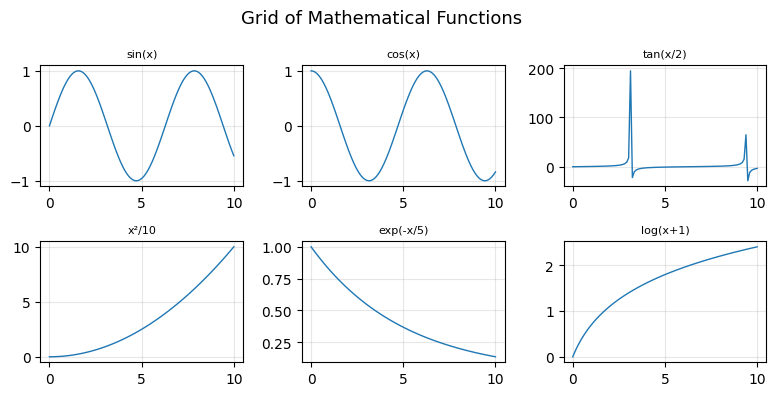

In [15]:
# Create 2x3 plots
fig, axes = plt.subplots(2, 3, figsize=(8,4))

# Flatten the 2D array to 1D for easy iteration
axes_flat = axes.ravel()

# Generate a list of different functions and their names
functions = [
    (np.sin(x), 'sin(x)'),
    (np.cos(x), 'cos(x)'),
    (np.tan(x/2), 'tan(x/2)'),
    (np.power(x,2)/10, 'x²/10'),
    (np.exp(-x/5), 'exp(-x/5)'),
    (np.log(x+1), 'log(x+1)'),
]#does 'lambda' create a function of 'x'(yes!) what is 'lambda'(it creates one line functions; lambda var: func)(like f(x) = func)

# create data
x = np.linspace(0, 10, 100)

#iterate through each axes, function and function name 
for ax, (func, title) in zip(axes_flat, functions):#read the list of axes together with the list of functions 
    ax.plot(x, func, linewidth=1)
    ax.set_title(title, fontsize=8)#is the title held within the functions in the list??
    ax.grid(True, alpha=0.3)

fig.suptitle('Grid of Mathematical Functions', fontsize=13, fontname='Calibri' )
fig.tight_layout()

plt.show()

In [16]:
a=[(1,1),(2,2),(3,3)]
b=[5,6,7]
#zip packages lists together so they can be read simultaneously
mylist = list(zip(a,b))#zip cant be printed on their own but can be converted into a printable list
for (x, y), z in mylist:
    print(x, y, z)

1 1 5
2 2 6
3 3 7


**`plt.subplots()` Main Parameters:**  

*Layout:*
- `nrows`, `ncols`: Number of rows and columns

*Sharing axes:*
- `sharex=True`: All subplots share the same x-axis
- `sharey=True`: All subplots share the same y-axis
- `sharex='col'`: Share x-axis within columns only
- `sharey='row'`: Share y-axis within rows only

*Subplot properties:*
- `subplot_kw=dict(...)`: Dictionary of kwargs passed to `add_subplot()`. E.g. `subplot_kw=dict(facecolor='lightgray')
 for background color

*Layout control:*
- `constrained_layout=True`: Automatic layout adjustment
- `gridspec_kw=dict(...)`: Dictionary of kwargs for GridSpec ([see below](#gridspec))

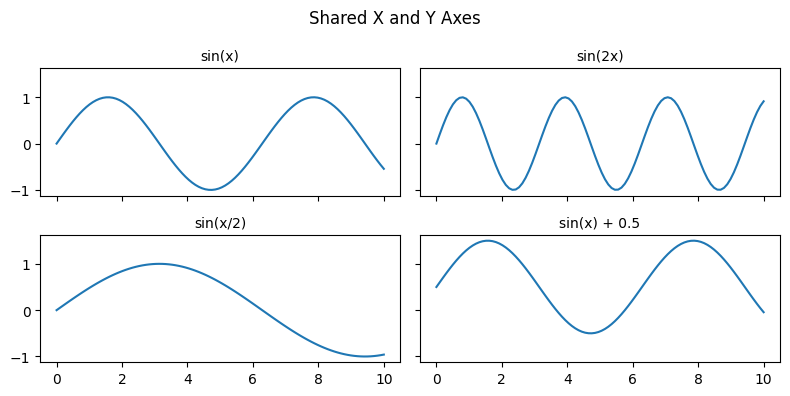

In [17]:
# 2x2 plots sharex and sharey
fig, axes = plt.subplots(2,2, figsize=(8,4), sharex= True, sharey= True) #creates both figure and subplots

# Create Data
x = np.linspace(0, 10, 100)
data_sets = [
    (np.sin(x), 'sin(x)'),
    (np.sin(2*x), 'sin(2x)'),
    (np.sin(x/2), 'sin(x/2)'),
    (np.sin(x) + 0.5, 'sin(x) + 0.5'),
]
# Iterate through
for ax, (data, title) in zip(axes.flatten(), data_sets):
    ax.plot(x, data)
    ax.set_title(title, size=10)

# Only bottom axes show x labels
# Only left axes show y labels
fig.suptitle('Shared X and Y Axes', fontsize=12)
fig.tight_layout()

plt.show()

#does not show the x and y axis for all plots unless you use "sharex" and "sharey"
#this is important for if you want to compare data with different scales

### Adjusting the layout of axes: `fig.subplots_adjust()` and  `fig.tight_layout()`

Matplotlib provides several ways to 'fine-tune' the layout of axes. One of them is `fig.subplots_adjust()`. This allows to adjust the layout of the axes **manually** .

**`fig.subplots_adjust()` Main Parameters:**

- `left` - Left side of the subplots area. Default: 0.125. Values: 0.0 to 1.0. e.g., left=0.1 (10% from left edge)
- `right` - Right side of the subplots area. Default: 0.9. Values: 0.0 to 1.0. e.g., right=0.95 (95% across from left edge)
- `bottom` - Bottom of the subplots area. Default: 0.1. Values: 0.0 to 1.0. e.g., bottom=0.15 (15% from bottom edge)
- `top` - Top of the subplots area. Default: 0.9. Values: 0.0 to 1.0. e.g., top=0.92 (92% from bottom edge)
- `wspace` - Width (horizontal) spacing between subplots. Default: 0.2. Values: 0.0 to 1.0 (fraction of average subplot width). e.g., wspace=0.3 (30% of subplot width as gap)
- `hspace` - Height (vertical) spacing between subplots. Default: 0.2. Values: 0.0 to 1.0 (fraction of average subplot height). e.g., hspace=0.4 (40% of subplot height as gap)

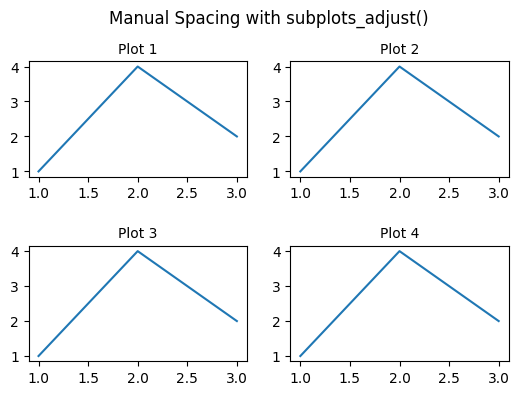

In [18]:
# Demonstrate spacing controls
fig, axes = plt.subplots(2, 2, figsize=(8, 4))

for i, ax in enumerate(axes.ravel(), 1):
    ax.plot([1, 2, 3], [1, 4, 2])
    ax.set_title(f'Plot {i}', size= 10)

# Adjust spacing manually
fig.subplots_adjust(
    left=0.2,    # Left margin
    right=0.8,  # Right margin
    bottom=0.1,  # Bottom margin
    top=0.85,    # Top margin
    wspace=0.2,  # Width space between subplots
    hspace=0.6   # Height space between subplots
)

fig.suptitle('Manual Spacing with subplots_adjust()', fontsize=12)
plt.show()

If you do not want to adjust manually, you can use `fig.tight_layout()` which will automatically adjust the layout to prevent overlapping elements.

**`fig.tight_layout()` Main parameters:**   
- `pad` - Padding between figure edge and subplots. e.g., pad=1.5 (default is 1.08)
- `h_pad` - Height padding between subplots. e.g., h_pad=2.0
- `w_pad` - Width padding between subplots. e.g., w_pad=2.0
- `rect` - Rectangle [left, bottom, right, top] in *Normalized Figure Coordinates* to fit subplots into. e.g., rect=[0, 0, 1, 0.95] (leave space at top for suptitle)

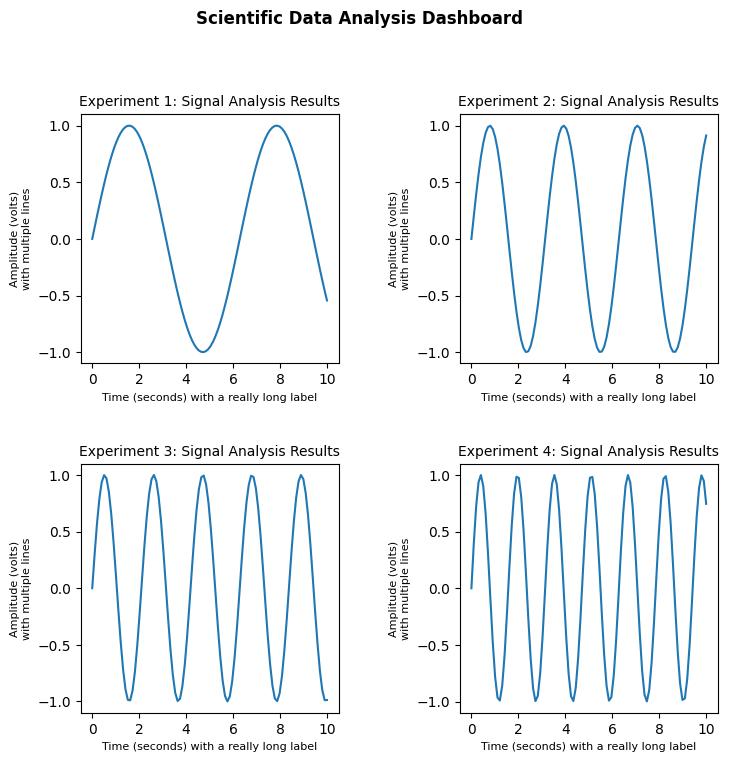

In [19]:
x = np.linspace(0, 10, 100)

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Add plots with long labels
for i, ax in enumerate(axes.flat):
    ax.plot(x, np.sin(x * (i+1)))
    ax.set_xlabel('Time (seconds) with a really long label', size= 8)
    ax.set_ylabel('Amplitude (volts)\nwith multiple lines', size= 8)
    ax.set_title(f'Experiment {i+1}: Signal Analysis Results', size= 10)

fig.suptitle('Scientific Data Analysis Dashboard', fontsize=12, fontweight='bold')

fig.tight_layout(
pad = 3.0
) 

plt.show()

Without `fig.tight_layout()`, matplotlib doesn't automatically adjust spacing. This causes:

- Labels get cut off at figure edges
- Titles overlap with other subplots
- Subplots overlap with each other

<a id='gridspec'></a>
###  GridSpec()
Matplotlib offers an additional way to layout Axes and that is through `GridSpec`. `GridSpec` divides a figure into a rectangular grid of cells you can address by row and column. Think of it as a layout blueprint: you declare the number of rows and columns, then place axes into one or more grid cells. `GridSpec` itself does not draw anything — it only describes where axes can go; you create axes with `fig.add_subplot(gs[row, col])` or `fig.add_subplot(gs[row_start:row_end, col_start:col_end])` to occupy one or more cells.

Slicing uses Python indexing semantics: the end index is exclusive. Here are some examples:
- **Single cell**: `fig.add_subplot(gs[1, 2])` places an axes in row 1, column 2.
- **Span rows**: `fig.add_subplot(gs[0:2, 0])` spans rows 0 and 1 in column 0.
- **Span columns**: `fig.add_subplot(gs[0, 0:3])` spans columns 0–2 in row 0.
- **Span both**: `fig.add_subplot(gs[0:2, 0:3])` creates a large axes covering a block of cells.

`GridSpec` can be confusing as you can call this functionality from three different locations:   
1. From a figure through `.add_gridspec()`.   
2. When using `.subplots(..., gridspec_kw=...)`.   
3. By importing the `GridSpec` object from `matplotlib.gridspec.GridSpec` (direct constructor).     

#### 1. `.add_gridspec()`

Use this when you want:
- A custom layout (spanning, asymmetry, mosaics)
- To manually place axes with fig.add_subplot(gs[row, col])
- A cleaner API than importing GridSpec directly

**This is the modern, recommended approach.**

**`.add_gridspec()`Main parameters:**
- `nrows` - Number of rows in the grid. e.g., nrows=3
- `ncols` - Number of columns in the grid, e.g., ncols=2
- `height_ratios` - Relative heights of rows. e.g., height_ratios=[2, 1, 1] (first row twice as tall)
- `width_ratios` - Relative widths of columns.  e.g., width_ratios=[3, 1] (first column three times wider)
- `hspace` - Vertical spacing between subplots. e.g., hspace=0.3
- `wspace` - Horizontal spacing between subplots. e.g., wspace=0.2
- `left, right, top, bottom` - Margins around the grid. e.g., left=0.1, right=0.9, top=0.9, bottom=0.1
- `figure` — auto-filled (you don’t pass it)

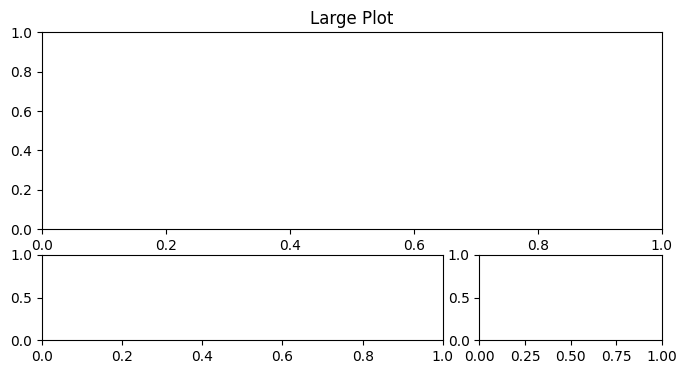

In [20]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 4))
gs = fig.add_gridspec(3, 3, wspace = 0.2, hspace = 0.3)# 3x3 grid

# Combine the first 3 axes in row 0 into one
ax1 = fig.add_subplot(gs[0:2, :])
ax1.set_title('Large Plot')
                      
# Three smaller subplots in the bottom row
ax2 = fig.add_subplot(gs[2, 0:2])
#ax3 = fig.add_subplot(gs[2, 1])
ax4 = fig.add_subplot(gs[2, 2])

#fig.tight_layout()
plt.show()

#### Width ratios and height ratios
`GridSpec` accepts `width_ratios` and `height_ratios` to control how much space each column or row gets relative to the others. They are lists of positive numbers:
- *Interpretation*: a column with ratio 3 is three times as wide as a column with ratio 1. Same for rows and height_ratios.
- *Units*: ratios are relative only; GridSpec converts them into actual figure-space fractions based on the figure size and margins.

#### Relationship between spanning and ratios
Spanning and ratios work together: spanning determines how many of those cells an axes occupies, and ratios set the grid cell sizes. The final axes size equals the sum of the sizes of the cells it spans (minus spacing/margins). Whe using `GridSpec`:

- Design in two steps: first decide the grid topology (how many rows/columns and which axes should span multiple cells), then assign ratios to tune relative sizes.

- Think additive: an axes spanning two columns gets width = column0_width + column1_width. If column0 has ratio 3 and column1 ratio 1, the spanning axes will be four “units” wide.

```{important} 
`wspace` and `hspace` (or `margins` when using `fig.tight_layout()`) subtract from available space. Large spacing reduces the visual size of spanned axes. Always preview and tweak spacing after setting ratios and spans.
```

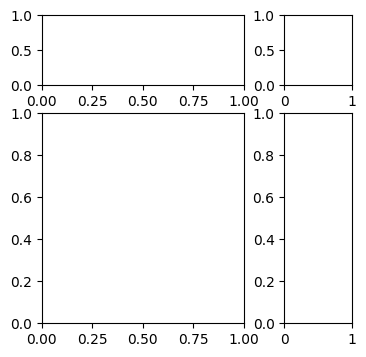

In [21]:
fig = plt.figure(figsize=(4, 4))
gs = fig.add_gridspec(2, 2, wspace = 0.3, width_ratios = [3,1], height_ratios = [1,3])  # 3x3 grid
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
plt.show()

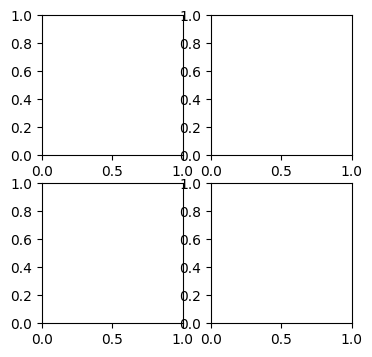

In [22]:
fig = plt.figure(figsize=(4, 4))
gs = fig.add_gridspec(2, 2, )  # 2x2 grid
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
plt.show()

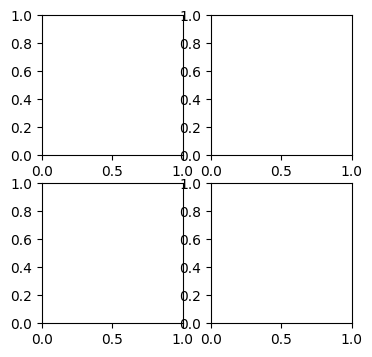

In [23]:
fig = plt.figure(figsize=(4, 4))
gs = fig.add_gridspec(2, 2, )  # 2x2 grid
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
plt.show()

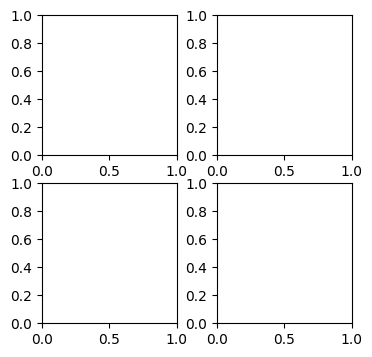

In [24]:
fig = plt.figure(figsize=(4, 4))
gs = fig.add_gridspec(2, 2, wspace= 0.3)  # 2x2 grid
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
plt.show()

#### 2. `.subplots(..., gridspec_kw=...)`
A way to customize the GridSpec that `subplots()` creates internally. You don’t get the GridSpec object directly. Yyou cannot control how axes are layout **ONLY** tweak its parameters, e.g. `wspace' so on.

**Main parameters:**    
- Same as above except for `nrows`, `ncols`

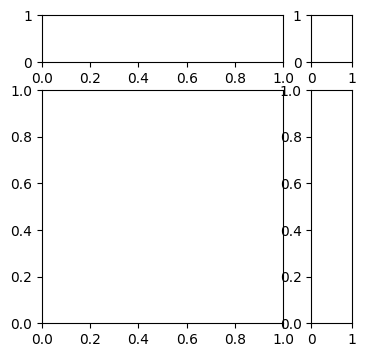

In [25]:
fig, ax = plt.subplots(2, 2,
                       figsize= (4,4),
                       gridspec_kw = {'width_ratios': [6,1], 'height_ratios': [1,5]}
                       #kw: keywords, a reference data structure within python
                       
)


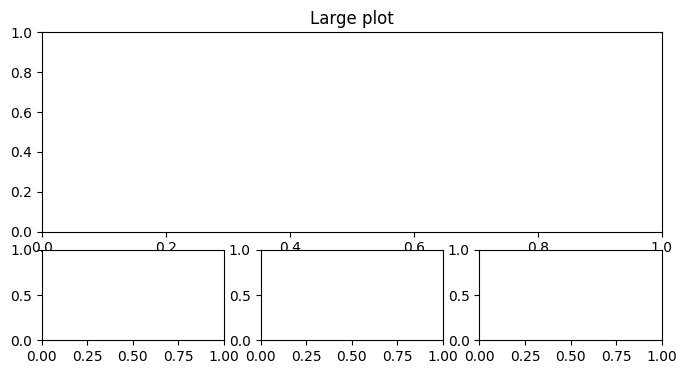

In [26]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(3, 3)  # 3x3 grid

# Large subplot spanning 2 rows and all columns
ax1 = fig.add_subplot(gs[0:2, :])
ax1.set_title('Large plot')

# Three smaller subplots in the bottom row
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[2, 1])
ax4 = fig.add_subplot(gs[2, 2])

#fig.tight_layout()
plt.show()

#### 3.  `matplotlib.gridspec.GridSpec`

The original, low-level constructor for `GridSpec` which is rarely used. It's functionality is identical to `fig.add_gridspec()`.

**Just do not use it**

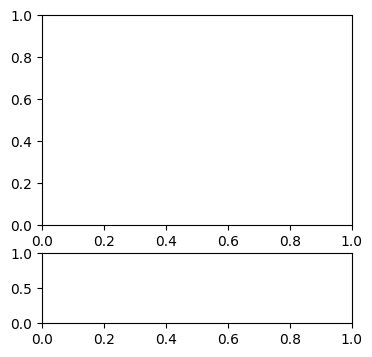

In [27]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(4, 4))
gs = GridSpec(2, 1, height_ratios=[3, 1])  # Top plot 3x larger
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
plt.show()

## Practical Example: Data Analysis Dashboard

Let's create a realistic data analysis figure using plt.subplots().

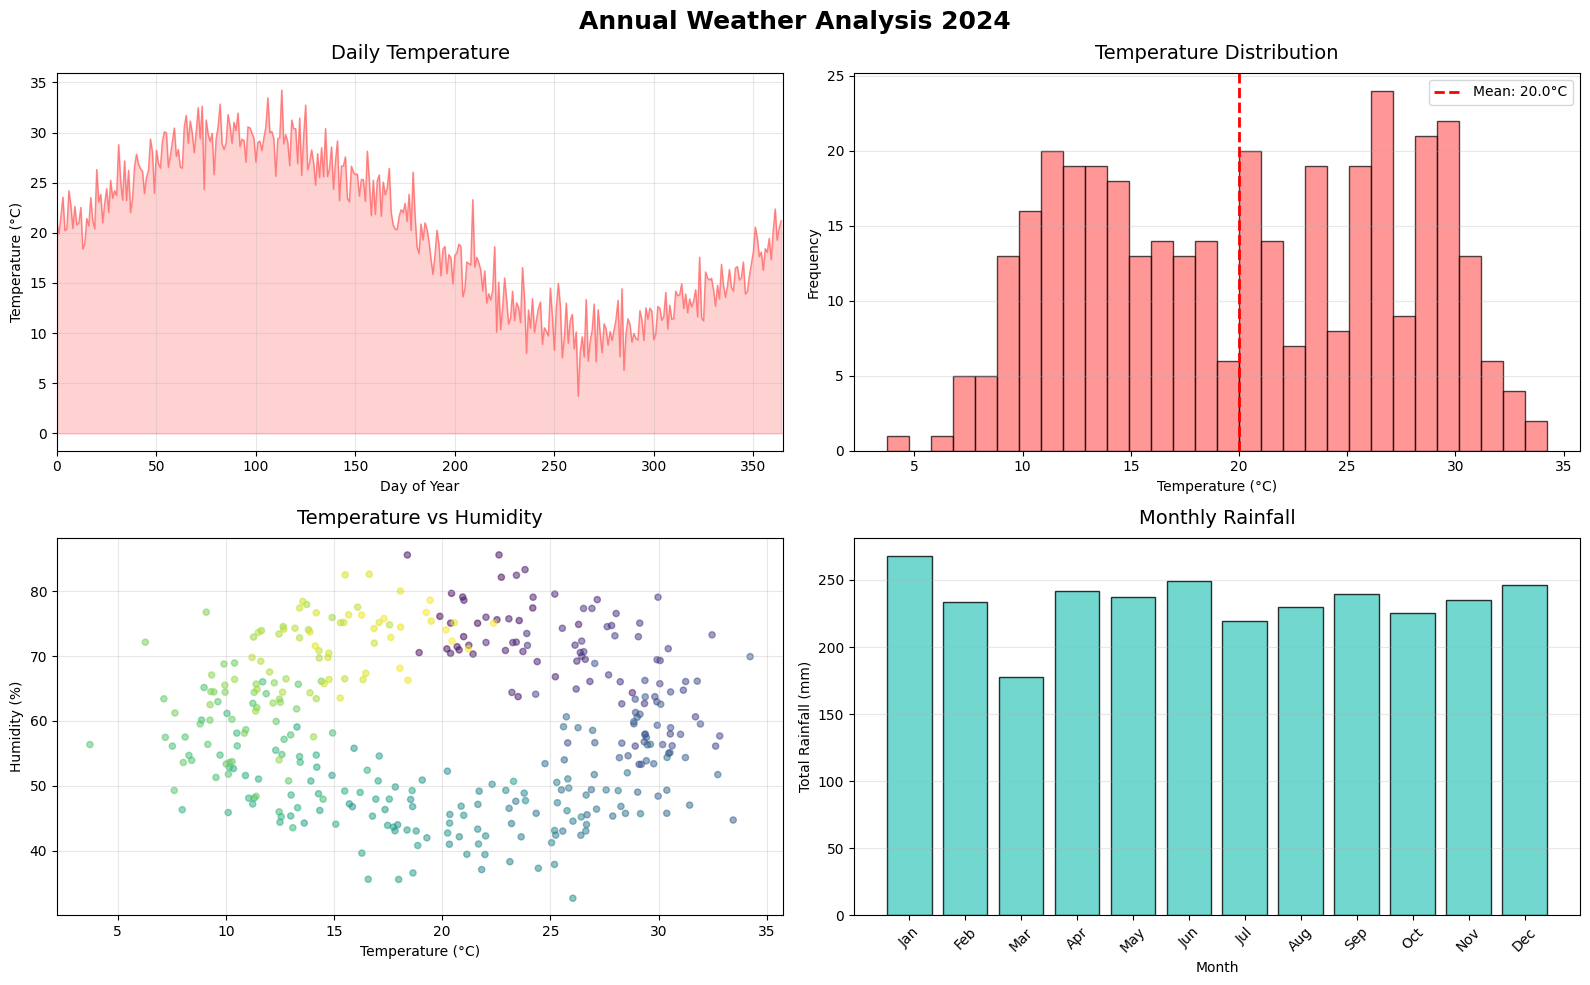

In [28]:
# Generate sample data
np.random.seed(42)
days = np.arange(365)
temperature = 20 + 10*np.sin(days/365 * 2*np.pi) + np.random.randn(365) * 2
humidity = 60 + 15*np.cos(days/365 * 2*np.pi) + np.random.randn(365) * 5
rainfall = np.abs(np.random.randn(365)) * 10

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Annual Weather Analysis 2024', fontsize=18, fontweight='bold', y=0.98)

# Temperature time series
axes[0, 0].plot(days, temperature, linewidth=1, alpha=0.8, color='#FF6B6B')
axes[0, 0].fill_between(days, temperature, alpha=0.3, color='#FF6B6B')
axes[0, 0].set_xlabel('Day of Year')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_title('Daily Temperature', fontsize=14, pad=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, 365)

# Temperature histogram
axes[0, 1].hist(temperature, bins=30, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Temperature Distribution', fontsize=14, pad=10)
axes[0, 1].axvline(temperature.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {temperature.mean():.1f}°C')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Humidity vs Temperature scatter
axes[1, 0].scatter(temperature, humidity, alpha=0.5, c=days, 
                   cmap='viridis', s=20)
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Humidity (%)')
axes[1, 0].set_title('Temperature vs Humidity', fontsize=14, pad=10)
axes[1, 0].grid(True, alpha=0.3)

# Monthly rainfall
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_rainfall = [rainfall[i*30:(i+1)*30].sum() for i in range(12)]
axes[1, 1].bar(months, monthly_rainfall, color='#4ECDC4', alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Rainfall (mm)')
axes[1, 1].set_title('Monthly Rainfall', fontsize=14, pad=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

fig.tight_layout()
plt.show()

## 2. Bar Charts - `bar()` and `barh()`

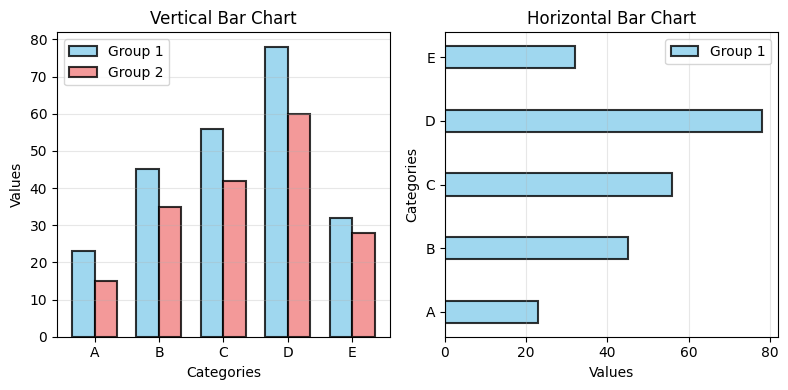

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Create data
categories = ['A', 'B', 'C', 'D', 'E']
series1 = [23, 45, 56, 78, 32]
series2 = [15, 35, 42, 60, 28]
x = np.arange(len(categories))

# Vertical bars
width = 0.35
# Series 1 plot 1
ax1.bar(x = x - width/2,
        height = series1,
        width = width,
        label='Group 1', color='skyblue', 
        edgecolor='black', linewidth=1.5, alpha=0.8)
# Series 2 plot 1
ax1.bar(x = x + width/2,
        height = series2,
        width = width,
        label='Group 2', color='lightcoral', 
        edgecolor='black', linewidth=1.5, alpha=0.8)

ax1.set_xlabel('Categories')
ax1.set_ylabel('Values')
ax1.set_title('Vertical Bar Chart')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Horizontal bars
ax2.barh(y = categories,
        width = series1,
        height = width,
        label='Group 1', color='skyblue',
         edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Values')
ax2.set_ylabel('Categories')
ax2.set_title('Horizontal Bar Chart')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

fig.tight_layout()
plt.show()

**Main bar()\barh()Parameters:**
- `x` - Bar positions (required)
- `height` (for `bar()`) or `width` (for `barh()`) - Bar heights/widths (required)
- `width` (for `bar()`) or `height` (for `barh()`) - Bar widths/heights (default: `0.8`, range: 0.0-1.0+)
- `bottom` (for `bar()`) or `left` (for `barh()`) - Base position (default: `0`, for stacked bars)
- `align` - Alignment (default: `'center'`, options: `'center'`, `'edge'`)
- `color` - Bar colors (default: from color cycle, single color or array)
- `edgecolor` - Edge color (default: `None`)
- `linewidth` - Edge line width (default: `0`, range: any positive float)
- `alpha` - Transparency (default: `1.0`, range: 0.0-1.0)
- `label` - Label for legend (default: `None`)

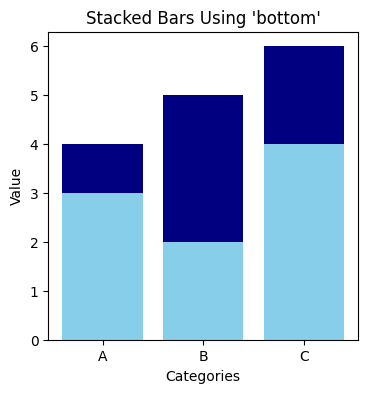

In [30]:
fig, ax = plt.subplots(figsize=(4,4))

categories= ['A', 'B', 'C']
y1 = [3, 2, 4]
y2 = [1, 3, 2]

# Bar 1
ax.bar(categories, y1, color = 'skyblue')

# Bar 2 Stacked
ax.bar(categories, y2, bottom=y1, color = 'navy')
 # illustrating: bottom
ax.set_title("Stacked Bars Using 'bottom'", size= 12)
ax.set_xlabel("Categories")
ax.set_ylabel("Value")
plt.show()


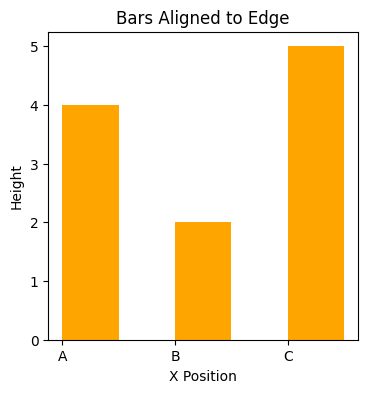

In [31]:
fig, ax = plt.subplots(figsize=(4,4))

categories= ['A', 'B', 'C']
heights = [4, 2, 5]

# Bar aligned edge
ax.bar(categories, heights, align = 'edge', width = 0.5, color = 'orange')
ax.set_title("Bars Aligned to Edge")
ax.set_xlabel("X Position")
ax.set_ylabel("Height")

plt.show()


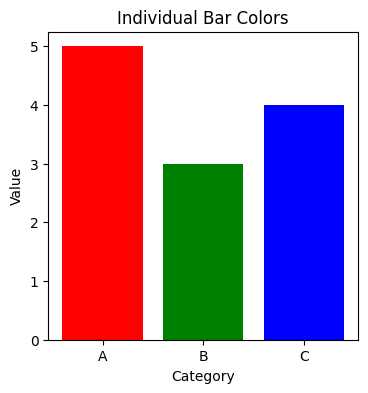

In [32]:
fig, ax = plt.subplots(figsize=(4,4))

categories= ['A', 'B', 'C']
values = [5, 3, 4]
colors=['red', 'green', 'blue']

# different colors
 # illustrating: color
ax.bar(categories, values, color = colors)
ax.set_title("Individual Bar Colors")
ax.set_xlabel("Category")
ax.set_ylabel("Value")

plt.show()


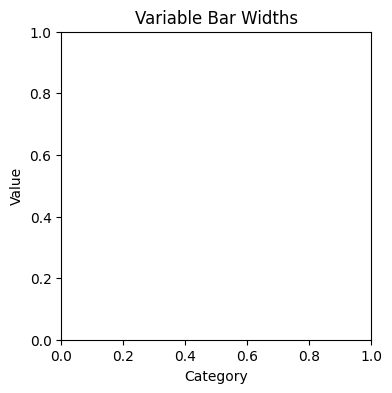

In [33]:
fig, ax = plt.subplots(figsize=(4,4))

categories= ['A', 'B', 'C']
values = [4, 6, 3]
widths=[0.2, 0.8, 0.4]

# different width Marimekko Chart
# illustrating: width

ax.set_title("Variable Bar Widths")
ax.set_xlabel("Category")
ax.set_ylabel("Value")

plt.show()
